In [55]:
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

In [56]:
df = pd.read_csv("../../dataset/SP500_Historical_Data.csv")
df

,Ticker,Date,Open,High,Low,Close,Adj Close,Volume
0,A,2000-01-03,47.07,47.18,40.27,43.04,43.04,4674353
1,A,2000-01-04,40.72,41.17,38.70,39.75,39.75,4765083
2,A,2000-01-05,39.60,39.75,36.05,37.28,37.28,5758642
3,A,2000-01-06,36.83,37.06,34.74,35.86,35.86,2534434
4,A,2000-01-07,35.30,39.41,35.27,38.85,38.85,2819626
...,...,...,...,...,...,...,...,...
2703526,ZS,2026-02-13,174.34,179.90,172.43,177.72,177.72,2434100
2703527,ZS,2026-02-17,175.82,176.85,169.61,172.59,172.59,2038100
2703528,ZS,2026-02-18,167.35,172.65,164.39,172.13,172.13,2542100
2703529,ZS,2026-02-19,169.64,172.10,166.30,168.99,168.99,3337100


## Visualize Dataset

In [57]:
tickets = df["Ticker"].unique()
print(df["Ticker"].unique())
print(df["Ticker"].nunique())
tickets

['A' 'AAL' 'AAPL' 'ABBV' 'ABNB' 'ABT' 'ACGL' 'ACN' 'ADBE' 'ADI' 'ADP'
 'AEE' 'AEP' 'AES' 'AFL' 'AIG' 'AIZ' 'AJG' 'AKAM' 'ALB' 'ALGN' 'ALL'
 'ALLE' 'AMAT' 'AMCR' 'AMD' 'AME' 'AMGN' 'AMP' 'AMT' 'AMZN' 'ANET' 'APA'
 'APD' 'APH' 'APP' 'APTV' 'ARE' 'ARES' 'ARM' 'ATO' 'AVB' 'AVGO' 'AVY'
 'AWK' 'AXON' 'AXP' 'AZO' 'BA' 'BAC' 'BALL' 'BAX' 'BBWI' 'BBY' 'BEN' 'BG'
 'BIIB' 'BIO' 'BK' 'BKNG' 'BKR' 'BLDR' 'BLK' 'BMY' 'BR' 'BRK.B' 'BRO'
 'BSX' 'BWA' 'BX' 'C' 'CAG' 'CAH' 'CARR' 'CAT' 'CB' 'CBOE' 'CBRE' 'CCI'
 'CCL' 'CDNS' 'CDW' 'CE' 'CEG' 'CF' 'CHRW' 'CHTR' 'CI' 'CINF' 'CL' 'CLX'
 'CMCSA' 'CME' 'CMG' 'CMI' 'CNC' 'CNP' 'COF' 'COIN' 'COO' 'COP' 'COST'
 'CPAY' 'CPB' 'CPRT' 'CPT' 'CRH' 'CRL' 'CRM' 'CRWD' 'CSCO' 'CSGP' 'CTAS'
 'CTRA' 'CTSH' 'CTVA' 'CVS' 'CVX' 'CZR' 'D' 'DAL' 'DASH' 'DAY' 'DD' 'DDOG'
 'DE' 'DECK' 'DELL' 'DG' 'DHI' 'DHR' 'DIS' 'DLR' 'DLTR' 'DOC' 'DOV' 'DOW'
 'DPZ' 'DRI' 'DTE' 'DUK' 'DVA' 'DVN' 'DXCM' 'EBAY' 'ECL' 'ED' 'EFX' 'EIX'
 'EL' 'EME' 'EMN' 'EMR' 'ENPH' 'EOG' 'EPAM' 'EQIX' 'EQR' 'EQT'

array(['A', 'AAL', 'AAPL', 'ABBV', 'ABNB', 'ABT', 'ACGL', 'ACN', 'ADBE',
       'ADI', 'ADP', 'AEE', 'AEP', 'AES', 'AFL', 'AIG', 'AIZ', 'AJG',
       'AKAM', 'ALB', 'ALGN', 'ALL', 'ALLE', 'AMAT', 'AMCR', 'AMD', 'AME',
       'AMGN', 'AMP', 'AMT', 'AMZN', 'ANET', 'APA', 'APD', 'APH', 'APP',
       'APTV', 'ARE', 'ARES', 'ARM', 'ATO', 'AVB', 'AVGO', 'AVY', 'AWK',
       'AXON', 'AXP', 'AZO', 'BA', 'BAC', 'BALL', 'BAX', 'BBWI', 'BBY',
       'BEN', 'BG', 'BIIB', 'BIO', 'BK', 'BKNG', 'BKR', 'BLDR', 'BLK',
       'BMY', 'BR', 'BRK.B', 'BRO', 'BSX', 'BWA', 'BX', 'C', 'CAG', 'CAH',
       'CARR', 'CAT', 'CB', 'CBOE', 'CBRE', 'CCI', 'CCL', 'CDNS', 'CDW',
       'CE', 'CEG', 'CF', 'CHRW', 'CHTR', 'CI', 'CINF', 'CL', 'CLX',
       'CMCSA', 'CME', 'CMG', 'CMI', 'CNC', 'CNP', 'COF', 'COIN', 'COO',
       'COP', 'COST', 'CPAY', 'CPB', 'CPRT', 'CPT', 'CRH', 'CRL', 'CRM',
       'CRWD', 'CSCO', 'CSGP', 'CTAS', 'CTRA', 'CTSH', 'CTVA', 'CVS',
       'CVX', 'CZR', 'D', 'DAL', 'DASH', 'DAY', 'DD', 'DDOG'

### Specify the observing stock

In [66]:
def get_stock_df(df, ticker):
    stock_df = df.loc[df["Ticker"] == ticker].copy()
    stock_df["Date"] = pd.to_datetime(stock_df["Date"])
    stock_df = stock_df.sort_values("Date")
    # Set [Date] Column as Primary Key
    stock_df = stock_df.set_index("Date")
    return stock_df

In [68]:
apple_df = get_stock_df(df, "AAPL")
apple_df

,Ticker,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,,
2000-01-03,AAPL,0.79,0.84,0.76,0.84,0.84,535796800
2000-01-04,AAPL,0.81,0.83,0.76,0.77,0.77,512377600
2000-01-05,AAPL,0.78,0.83,0.77,0.78,0.78,778321600
2000-01-06,AAPL,0.79,0.80,0.71,0.71,0.71,767972800
2000-01-07,AAPL,0.72,0.76,0.72,0.75,0.75,460734400
...,...,...,...,...,...,...,...
2026-02-13,AAPL,262.01,262.23,255.45,255.78,255.78,56290700
2026-02-17,AAPL,258.05,266.29,255.54,263.88,263.88,58469100
2026-02-18,AAPL,263.60,266.82,262.45,264.35,264.35,34203300


In [69]:
apple_last_year_df = apple_df.last("365D")
apple_last_year_df

/var/folders/lp/hgbg7xdj7ql_zq41nk0lt6yw0000gn/T/ipykernel_77824/536473581.py:1: FutureWarning: last is deprecated and will be removed in a future version. Please create a mask and filter using `.loc` instead
  apple_last_year_df = apple_df.last("365D")


,Ticker,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,,
2025-02-21,AAPL,244.88,247.61,244.16,244.48,244.48,53197400
2025-02-24,AAPL,243.87,247.78,243.36,246.03,246.03,51326400
2025-02-25,AAPL,246.92,248.92,243.85,245.97,245.97,48013300
2025-02-26,AAPL,243.27,243.92,238.09,239.32,239.32,44433600
2025-02-27,AAPL,238.37,241.41,236.03,236.27,236.27,41153600
...,...,...,...,...,...,...,...
2026-02-13,AAPL,262.01,262.23,255.45,255.78,255.78,56290700
2026-02-17,AAPL,258.05,266.29,255.54,263.88,263.88,58469100
2026-02-18,AAPL,263.60,266.82,262.45,264.35,264.35,34203300


### Visualize with Candlestick Chart

In [70]:
import mplfinance as mpf

In [72]:
print(apple_last_year_df.index)

DatetimeIndex(['2025-02-21', '2025-02-24', '2025-02-25', '2025-02-26',
               '2025-02-27', '2025-02-28', '2025-03-03', '2025-03-04',
               '2025-03-05', '2025-03-06',
               ...
               '2026-02-06', '2026-02-09', '2026-02-10', '2026-02-11',
               '2026-02-12', '2026-02-13', '2026-02-17', '2026-02-18',
               '2026-02-19', '2026-02-20'],
              dtype='datetime64[ns]', name='Date', length=251, freq=None)


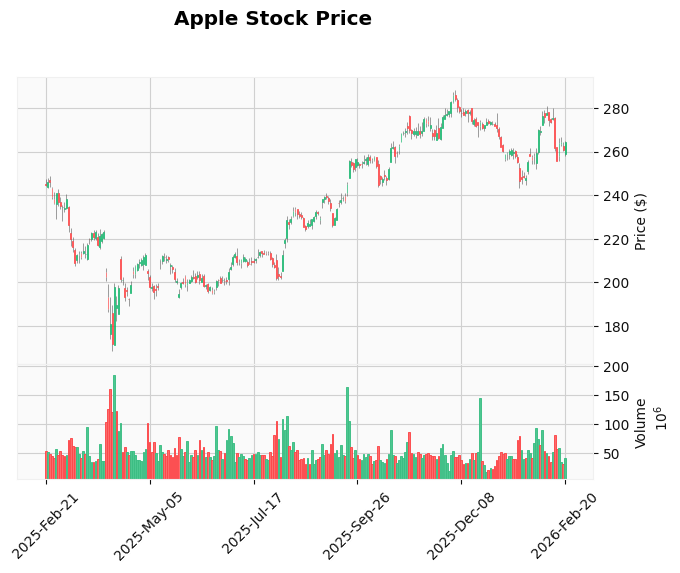

In [77]:
mpf.plot(
    apple_last_year_df,
    type="candle",
    style="yahoo",
    volume=True,
    title="Apple Stock Price",
    ylabel="Price ($)",
    ylabel_lower="Volume"
)

### Visualize with Using Simple Moving Averages (SMA20 & SMA50)

- <b>SMA20 (Simple Moving Average 20):</b> Represents the short-term market trend. Since it reacts relatively quickly to recent price movements, it is commonly used to detect short-term mommentum and potential trend reversals.
 
- <b>SMA50 (Simple Moving Average 50):</b> Represents the medium=term market trend. Compared with SMA20, it changes more slowly and is generally used to confirm the overall diection of the market.


<img src="../asset/img/005_img_AA002FAI.png" width="1000" height="200">

In [79]:
apple_last_year_df["SMA20"] = (
    apple_last_year_df["Close"]
    .rolling(window=20)
    .mean()
)

apple_last_year_df["SMA50"] = (
    apple_last_year_df["Close"]
    .rolling(window=50)
    .mean()
)

/var/folders/lp/hgbg7xdj7ql_zq41nk0lt6yw0000gn/T/ipykernel_77824/3540330630.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  apple_last_year_df["SMA20"] = (
/var/folders/lp/hgbg7xdj7ql_zq41nk0lt6yw0000gn/T/ipykernel_77824/3540330630.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  apple_last_year_df["SMA50"] = (


In [ ]:
apple_last_year_df

In [83]:
# Plot SMA into the Histogram
apds = [
    mpf.make_addplot(
        apple_last_year_df["SMA20"],
        color="green",
        width=1.2
    ),
    mpf.make_addplot(
        apple_last_year_df["SMA50"],
        color="red",
        width=1.2
    )
]

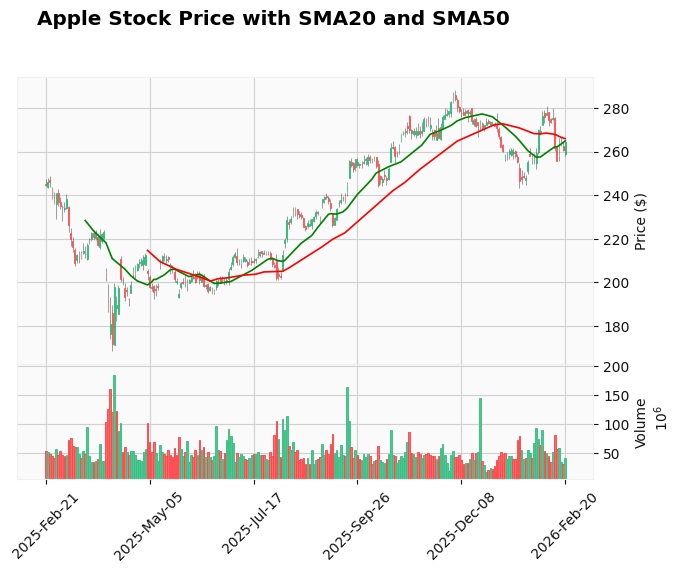

In [84]:
mpf.plot(
    apple_last_year_df,
    type="candle",
    style="yahoo",
    volume=True,
    addplot=apds,
    title="Apple Stock Price with SMA20 and SMA50",
    ylabel="Price ($)",
    ylabel_lower="Volume"
)

### Visualize with Relative Strength Index

<b>Relative Strength Index (RSI): </b> Measures the speed and magnitude of recent price movements to evaluate wheter a stock is potentially overbought or oversold.

- <b>Overbought Region: </b> [RSI > 70] : A value above 70 indicates that buying pressure has been unusually strong. Thr stock may become overbought, suggesting that a short-term price correction could occur.

- <b>Oversold Region: </b> [RSI < 30] : A value below 30 indicates excessive sellig pressure. The stock may become oversold, suggesting a potiential price rebound.

- <b>Neutral Zone: </b> [30≤RSI≤70] : The market is generally considered to be a normal trading condition without extreme momemtum.

<img src="../asset/img/006_img_AA002FAI.png" width="800" height="500">


In [ ]:
import pandas_ta as ta

apple_last_year_df["RSI"] = ta.rsi(
    apple_last_year_df["Close"],
    length=14
)

apple_last_year_df

In [86]:
apds = [

    mpf.make_addplot(
        apple_last_year_df["SMA20"],
        color="blue"
    ),

    mpf.make_addplot(
        apple_last_year_df["SMA50"],
        color="orange"
    ),

    mpf.make_addplot(
        apple_last_year_df["RSI"],
        panel=1,
        ylabel="RSI",
        color="purple"
    )

]

In [87]:
rsi70 = np.full(len(apple_last_year_df), 70)
rsi30 = np.full(len(apple_last_year_df), 30)

In [88]:
apds.extend([

    mpf.make_addplot(
        rsi70,
        panel=1,
        color="red",
        linestyle="--"
    ),

    mpf.make_addplot(
        rsi30,
        panel=1,
        color="green",
        linestyle="--"
    )

])

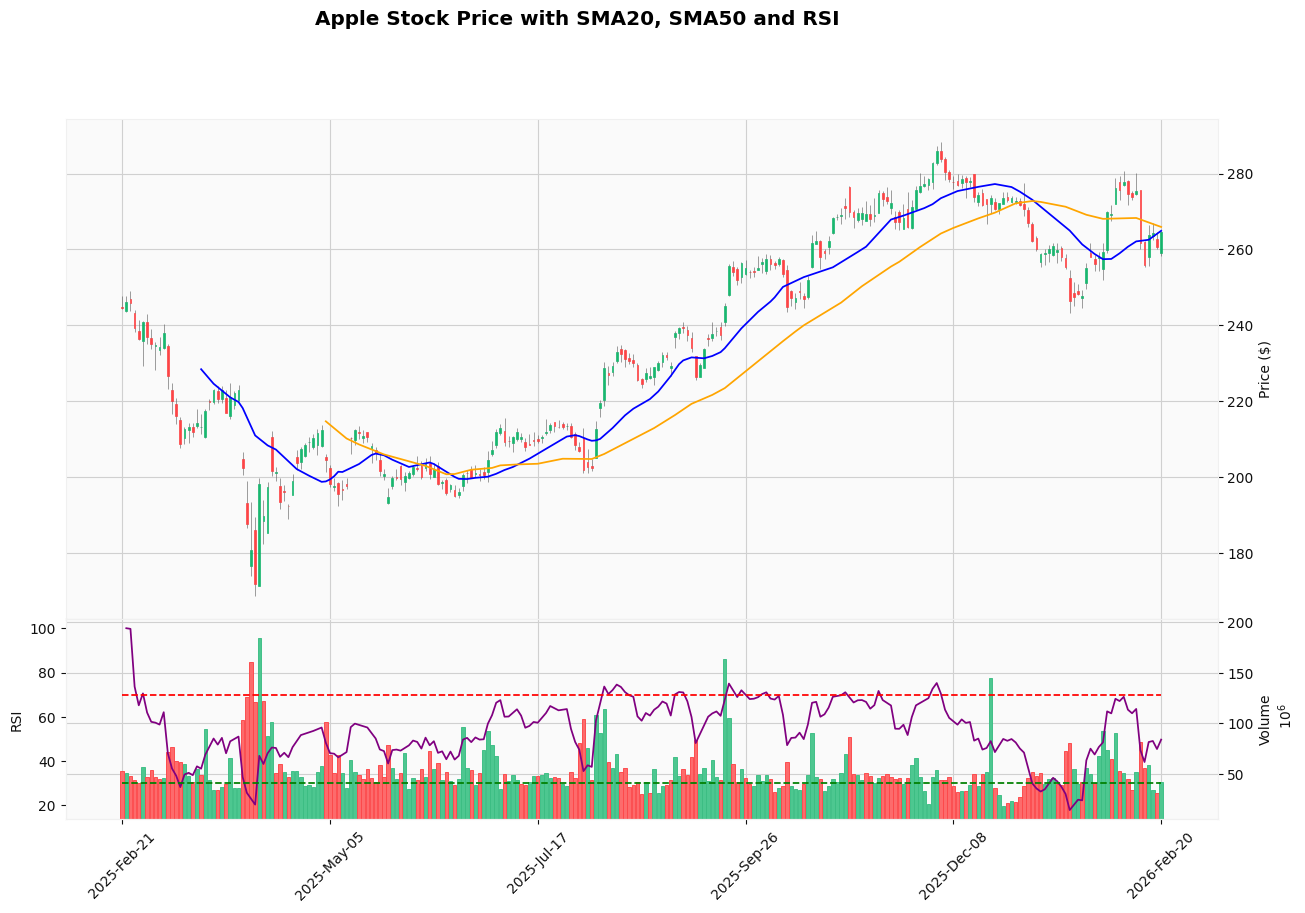

In [89]:
mpf.plot(
    apple_last_year_df,
    type="candle",
    style="yahoo",
    volume=True,
    addplot=apds,
    title="Apple Stock Price with SMA20, SMA50 and RSI",
    ylabel="Price ($)",
    ylabel_lower="Volume",
    figsize=(16,10)
)

### Visualize with Moving Average Convergence Divergence (MACD)

- <b>MACD: </b> Measures the relationship between two Exponential Moving Averages (EMAs) of a stock's closing price. Unlike SMA. the EMA assigns greater weight to recent prices, allowing it to respond more quickly to changes in market momentum.

The MACD indicator consists of three components:
- MACD Line.
- Signal Line.
- Histogram


<img src="../asset/img/007_img_AA002FAI.png" width="800" height="500">

<img src="../asset/img/008_img_AA002FAI.png" width="800" height="500">

<img src="../asset/img/009_img_AA002FAI.png" width="800" height="150">

<img src="../asset/img/010_img_AA002FAI.png" width="800" height="150">

In [ ]:
macd = ta.macd(
    apple_last_year_df["Close"],
    fast=12,
    slow=26,
    signal=9
)

In [ ]:
apple_last_year_df = apple_last_year_df.join(macd)
apple_last_year_df

In [92]:
apds.extend([
    mpf.make_addplot(
        apple_last_year_df["MACD_12_26_9"],
        panel=2,
        color="blue",
        ylabel="MACD"
    ),
    mpf.make_addplot(
        apple_last_year_df["MACDs_12_26_9"],
        panel=2,
        color="red"
    ),
    mpf.make_addplot(
        apple_last_year_df["MACDh_12_26_9"],
        panel=2,
        type="bar"
    )
])

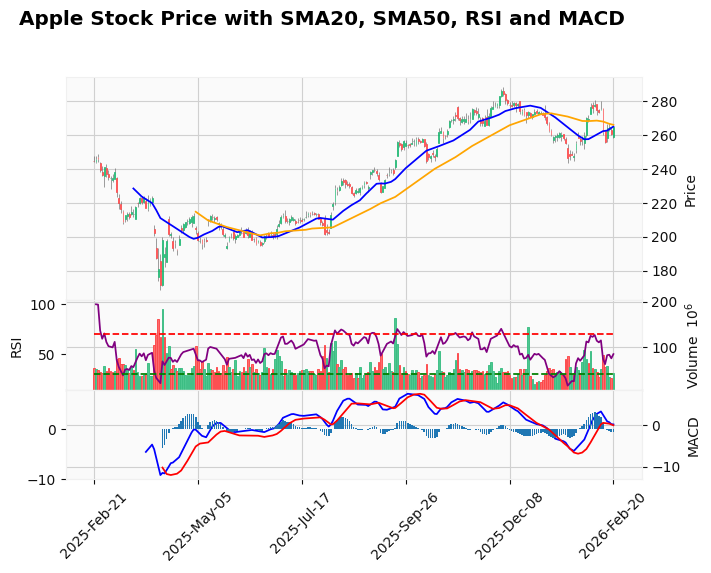

In [93]:
mpf.plot(
    apple_last_year_df,
    type="candle",
    volume=True,
    addplot=apds,
    style="yahoo",
    title="Apple Stock Price with SMA20, SMA50, RSI and MACD"
)

### Correlation Matrix Heatmap

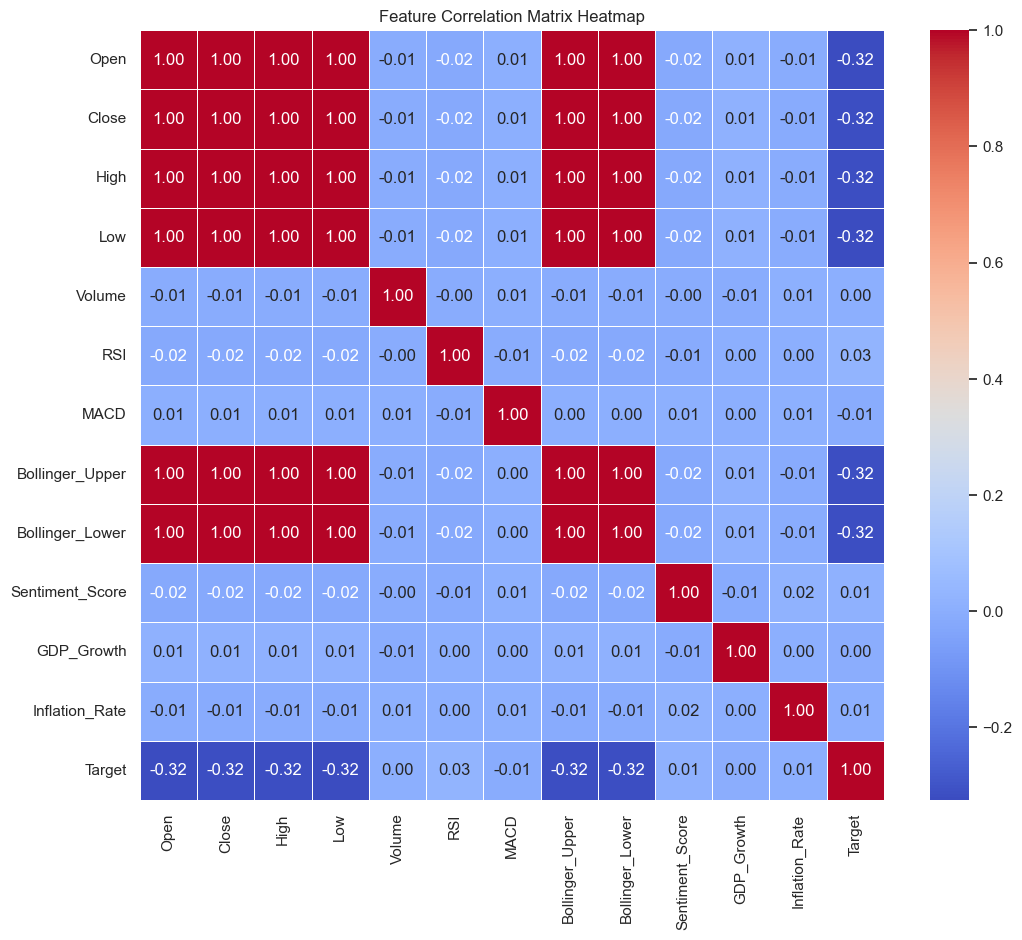

In [10]:
plt.figure(figsize=(12,10))
# Calculate Pearson correlation matrix
corr_matrix = df.corr()

# Generate the heatmap
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5)
plt.title('Feature Correlation Matrix Heatmap')
plt.show()

### Feature Behavior by Target Class (Boxplots)

/var/folders/lp/hgbg7xdj7ql_zq41nk0lt6yw0000gn/T/ipykernel_77824/2648370508.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Target', y=col, data=df, ax=axes[i], palette='Pastel1')
/var/folders/lp/hgbg7xdj7ql_zq41nk0lt6yw0000gn/T/ipykernel_77824/2648370508.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Target', y=col, data=df, ax=axes[i], palette='Pastel1')
/var/folders/lp/hgbg7xdj7ql_zq41nk0lt6yw0000gn/T/ipykernel_77824/2648370508.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Target', y=col, data=df, ax=axes[i], palet

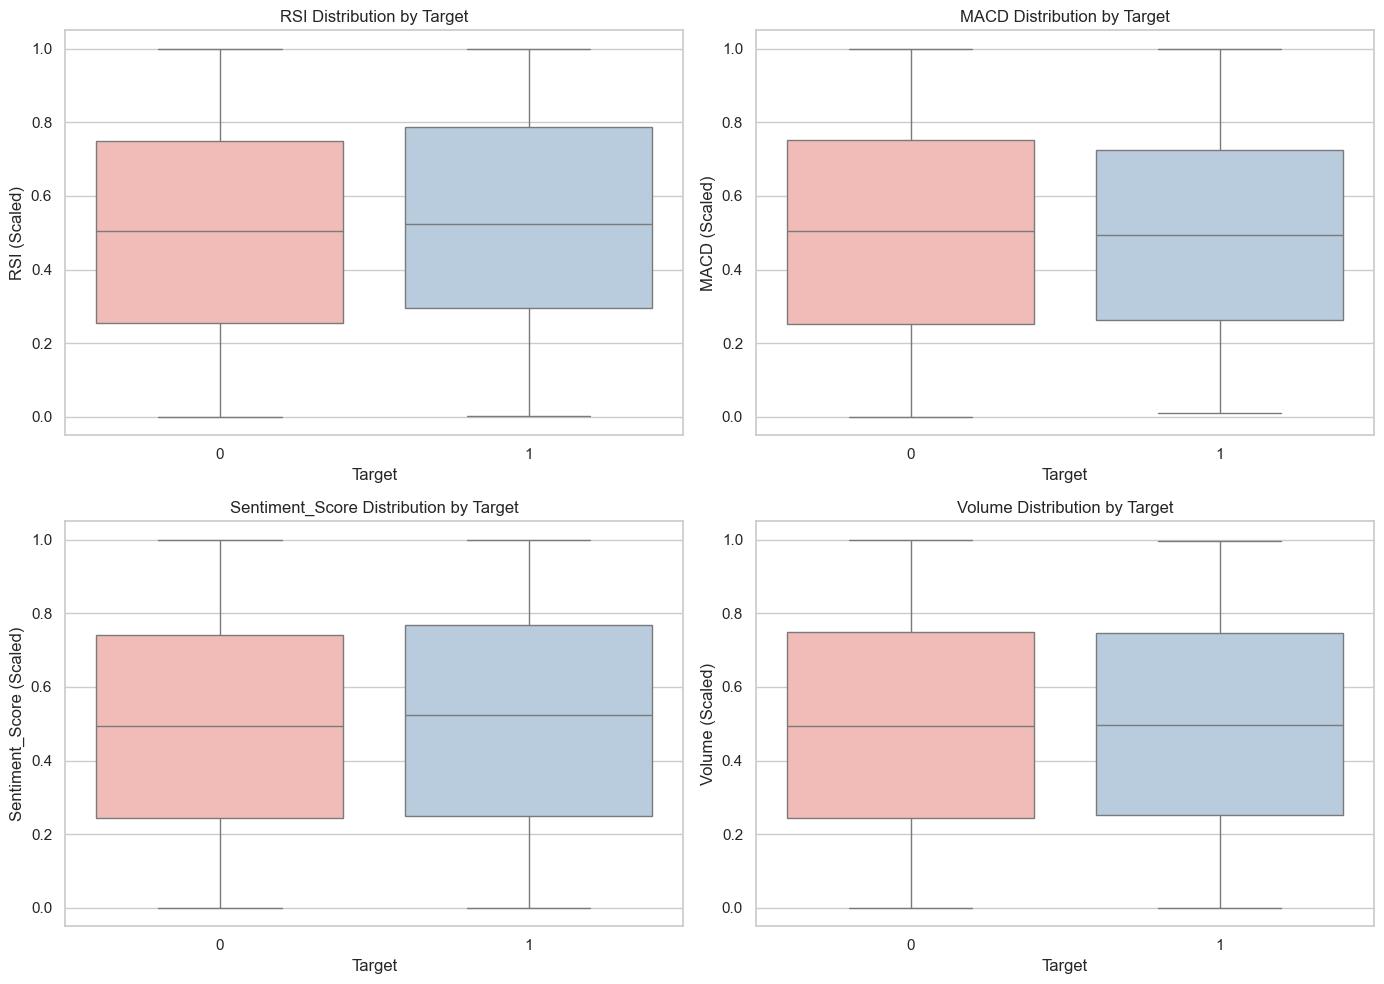

In [13]:
# Select key representative features for analysis
features_to_plot = ["RSI", "MACD", "Sentiment_Score", "Volume"]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(features_to_plot):
    sns.boxplot(x='Target', y=col, data=df, ax=axes[i], palette='Pastel1')
    axes[i].set_title(f'{col} Distribution by Target')
    axes[i].set_xlabel('Target')
    axes[i].set_ylabel(f'{col} (Scaled)')

plt.tight_layout()
plt.show()


### 2D Feature Interaction & Decision Space

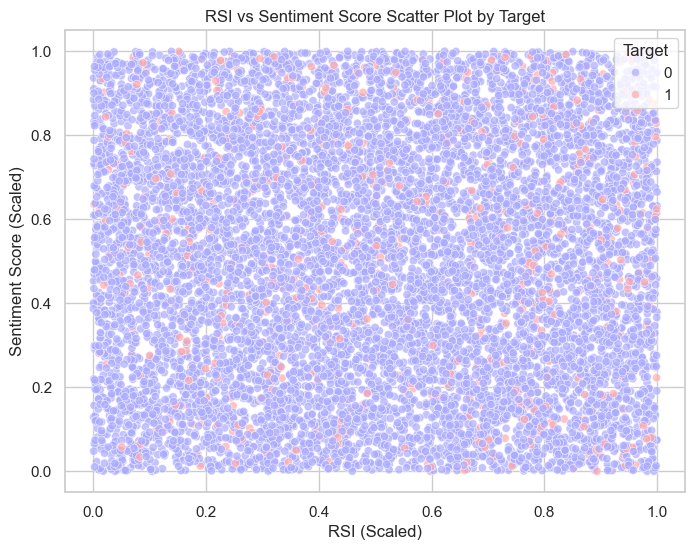

In [14]:
plt.figure(figsize=(8, 6))

# Plot the scatter distribution colored by Target
sns.scatterplot(x='RSI', y='Sentiment_Score', hue='Target', data=df, palette='bwr', alpha=0.7)
plt.title('RSI vs Sentiment Score Scatter Plot by Target')
plt.xlabel('RSI (Scaled)')
plt.ylabel('Sentiment Score (Scaled)')
plt.legend(title='Target')
plt.show()

### Time-Series Price Trend and Target Overlay

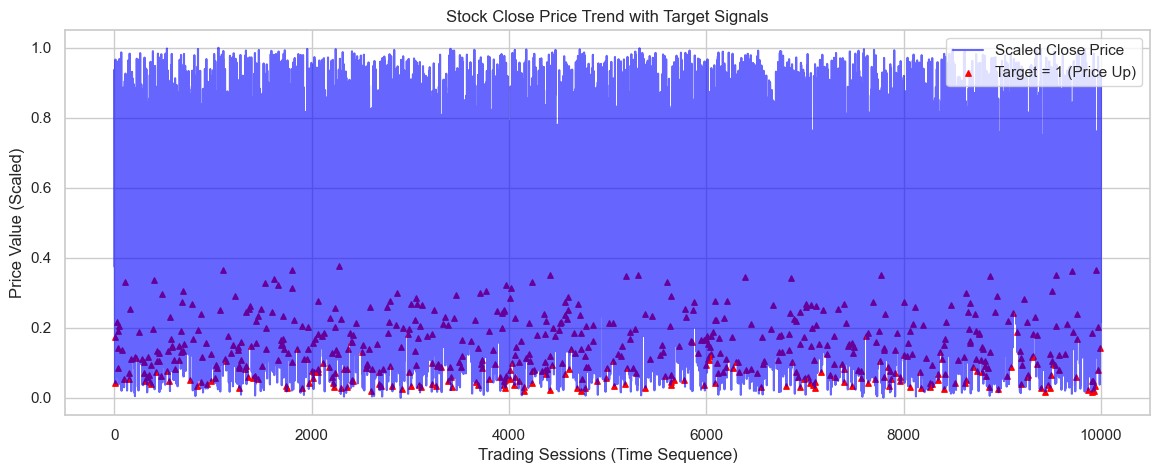

In [15]:
plt.figure(figsize=(14, 5))

# Plot the continuous scaled Close price
plt.plot(df['Close'], label='Scaled Close Price', color='blue', alpha=0.6)

# Overlay the positive target signals (Price Up) as red triangles
up_signals = df[df['Target'] == 1]
plt.scatter(up_signals.index, up_signals['Close'], color='red', marker='^', label='Target = 1 (Price Up)', s=15)

plt.title('Stock Close Price Trend with Target Signals')
plt.xlabel('Trading Sessions (Time Sequence)')
plt.ylabel('Price Value (Scaled)')
plt.legend()
plt.show()